# Atelier — Préparation de Données Tabulaires

---
# Partie 1 – Explorer les données


## 1) Charger les données CSV

In [68]:
# importer les packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [69]:
# charger le fichier
df = pd.read_csv("../data/smart_building_raw.csv", parse_dates=["date"])
df.shape


(507, 14)

## 2) Afficher les premières lignes du dataset

In [70]:
# Afficher les premières lignes du dataset
df.head()


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


## 3) Afficher les dernières lignes du dataset

In [71]:
# Afficher les dernieres lignes du dataset
df.tail()


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


## 4) Combien d'observations contient le dataset ?

In [72]:
print(f"Le dataset contient {df.shape[0]} observations.")


Le dataset contient 507 observations.


## 5) Combien de variables possède le dataset ?

In [73]:
print(f"Le dataset contient {df.shape[1]} variables (colonnes).")


Le dataset contient 14 variables (colonnes).


## 6) Identifier les variables numériques

In [74]:
df.select_dtypes(include=['number']).columns


Index(['id_mesure', 'temperature', 'humidite', 'co2', 'occupation',
       'consommation_kwh'],
      dtype='object')

## 7) Identifier les variables catégorielles

In [75]:
df.select_dtypes(include=['object']).columns


Index(['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation',
       'etat_systeme', 'jour_semaine', 'alerte'],
      dtype='object')

## 8) Identifier les dates

In [76]:
date = df["date"]
print(date)


0      2025-02-13 06:00:00
1      2025-03-10 12:00:00
2      2025-05-04 00:00:00
3      2025-01-19 00:00:00
4      2025-04-24 06:00:00
              ...         
502    2025-01-27 12:00:00
503    2025-03-09 12:00:00
504    2025-03-29 00:00:00
505    2025-04-19 18:00:00
506    2025-01-26 12:00:00
Name: date, Length: 507, dtype: object


## 9) Identifier les identifiants

In [77]:
identifiants = df["id_mesure"]
print(identifiants)


0      1174
1      1275
2      1493
3      1073
4      1454
       ... 
502    1107
503    1271
504    1349
505    1436
506    1103
Name: id_mesure, Length: 507, dtype: int64


## 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles

In [78]:
df.describe()


,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


## 11) Y a-t-il des variables potentiellement problématiques ?

- `temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh` : valeurs manquantes ET
  valeurs manifestement impossibles (min/max très éloignés des bornes physiques attendues :
  humidité négative ou > 100%, température > 30°C ou négative extrême, consommation négative...).
- `type_batiment`, `mode_climatisation`, `etat_systeme` : catégories mal orthographiées, casse
  et espaces incohérents (ex. `"Bureu"`, `" eco"`, `"NORMAL"`).
- `alerte` : à vérifier — suspicion de déséquilibre de classes (Partie 1.18).
- `id_mesure` : à vérifier pour les doublons (Partie 1.14).


## 12) Pour les données incohérentes :

**a) rechercher des valeurs telles que humidité < 0**

In [79]:
humidite_negatives = df[df['humidite'] < 0]
print(humidite_negatives)


     id_mesure                 date batiment type_batiment zone  temperature  \
281       1126  2025-02-01 06:00:00       B2         École    D         24.8   
335       1036  2025-01-09 18:00:00       B4        Bureau    D         21.2   
366       1216  2025-02-23 18:00:00       B3       Hôpital    B         23.2   

     humidite    co2  occupation  consommation_kwh mode_climatisation  \
281      -5.0  759.0        57.0             225.2              Boost   
335      -8.0  160.0        25.0             120.2             Normal   
366     -12.0  702.0        41.0             119.8             Normal   

    etat_systeme jour_semaine alerte  
281       Normal       Samedi    Non  
335       Alerte        Jeudi    Non  
366       Normal     Dimanche    Non  


**b) rechercher des valeurs telles que humidité > 100**

In [80]:
humidite_sup_100 = df[df['humidite'] > 100]
print(humidite_sup_100)


     id_mesure                 date batiment      type_batiment zone  \
59        1246  2025-03-03 06:00:00       B5  Centre commercial    A   
103       1016  2025-01-04 18:00:00       B6         Université    B   
128       1156  2025-02-08 18:00:00       B1             Bureau    A   
160       1186  2025-02-16 06:00:00       B8           Entrepôt    B   
268       1276  2025-03-10 18:00:00       B1             Bureau    D   
327       1066  2025-01-17 06:00:00       B2              École    C   
342       1096  2025-01-24 18:00:00       B8           Entrepôt    A   

     temperature  humidite    co2  occupation  consommation_kwh  \
59          24.2     108.0  813.0        18.0             -15.0   
103         26.9     145.0  670.0        28.0             175.9   
128          NaN     160.0  941.0        37.0             149.8   
160         24.9     125.0    NaN        18.0             123.5   
268         26.0     140.0  633.0        25.0             148.3   
327         25.8     

**c) rechercher des valeurs telles que température extrêmement élevée**

In [81]:
print(df['temperature'].mean())


24.154141414141414


In [82]:
temp_extr = df[df['temperature'] > 30]
print(temp_extr)


     id_mesure                 date batiment      type_batiment zone  \
7         1141  2025-02-05 00:00:00       B2              École    D   
48        1472  2025-04-28 18:00:00       B3            Hôpital    C   
116       1181  2025-02-15 00:00:00       B6         Université    A   
157       1361  2025-04-01 00:00:00       B3            Hôpital    D   
161       1061  2025-01-16 00:00:00       B5  Centre commercial    D   
189       1068  2025-01-17 18:00:00       B7             Bureau    C   
199       1146  2025-02-06 06:00:00       B7              Bureu    C   
277       1355  2025-03-30 12:00:00       B5  Centre commercial    C   
370       1268  2025-03-08 18:00:00       B1             Bureau    B   
393       1157  2025-02-09 00:00:00       B8           Entrepôt    B   
419       1191  2025-02-17 12:00:00       B2              École    D   
429       1420  2025-04-15 18:00:00       B5  Centre commercial    D   
490       1100  2025-01-25 18:00:00       B7             Bureau 

**d) rechercher des valeurs telles que occupation négative**

In [83]:
occupation_negative = df[df['occupation'] < 0]
print(occupation_negative)


     id_mesure                 date batiment      type_batiment zone  \
22        1031  2025-01-08 12:00:00       B2              École    D   
376       1231  2025-02-27 12:00:00       B7             Bureau    D   
430       1081  2025-01-21 00:00:00       B1             Bureau    B   
487       1131  2025-02-02 12:00:00       B1           entrepot    A   
494       1331  2025-03-24 12:00:00       B5  Centre commercial    B   

     temperature  humidite     co2  occupation  consommation_kwh  \
22          26.1      57.6   648.0        -5.0             170.0   
376         19.0      35.3   680.0        -8.0             167.9   
430         23.5      44.1   541.0       -12.0             248.7   
487         26.3      70.6  1519.0        -2.0             173.4   
494         22.7      54.6   979.0       -20.0             178.6   

    mode_climatisation etat_systeme jour_semaine alerte  
22                 Eco       Normal     Mercredi    Non  
376                Eco       Alerte       

**e) rechercher des valeurs telles que consommation négative**

In [84]:
consommation_negative = df[df['consommation_kwh'] < 0]
print(consommation_negative)


     id_mesure                 date batiment      type_batiment zone  \
59        1246  2025-03-03 06:00:00       B5  Centre commercial    A   
154       1046  2025-01-12 06:00:00       B2              École    B   
199       1146  2025-02-06 06:00:00       B7              Bureu    C   
441       1346  2025-03-28 06:00:00       B5  Centre commercial    D   

     temperature  humidite    co2  occupation  consommation_kwh  \
59          24.2     108.0  813.0        18.0             -15.0   
154         21.0      59.4  894.0        33.0             -50.0   
199         32.2      53.8  621.0       103.0             -20.0   
441         29.0      44.1  834.0         6.0            -100.0   

    mode_climatisation etat_systeme jour_semaine alerte  
59              Normal       Normal        Lundi    Non  
154             Normal       Normal     Dimanche    Non  
199             Normal       Normal        Jeudi    Non  
441                Eco       Normal     Vendredi    Non  


**f) Si une valeur est manifestement erronée et qu'on ne peut pas retrouver sa vraie valeur,
la transformer en valeur manquante**

Une humidité hors de `[0, 100]`, une température extrême (ici on fixe le seuil métier à 30°C
au-dessus duquel une mesure de bâtiment est jugée irréaliste), une occupation négative ou une
consommation négative n'ont pas de "vraie valeur" récupérable : impossible de deviner la bonne
mesure, donc on les transforme en `NaN` plutôt que de les supprimer ou de les inventer.


In [85]:
df.loc[(df['humidite'] < 0) | (df['humidite'] > 100), 'humidite'] = np.nan
df.loc[df['temperature'] > 30, 'temperature'] = np.nan
df.loc[df['occupation'] < 0, 'occupation'] = np.nan
df.loc[df['consommation_kwh'] < 0, 'consommation_kwh'] = np.nan

print("Valeurs manquantes après transformation des incohérences :")
print(df[['temperature', 'humidite', 'occupation', 'consommation_kwh']].isna().sum())


Valeurs manquantes après transformation des incohérences :
temperature         26
humidite            21
occupation          11
consommation_kwh     9
dtype: int64


**g) rechercher des valeurs telles que catégories mal orthographiées**

In [86]:
for col in ['type_batiment', 'mode_climatisation', 'etat_systeme']:
    print(col, "-> valeurs uniques avant nettoyage :")
    print(sorted(df[col].dropna().unique()))
    print()


type_batiment -> valeurs uniques avant nettoyage :
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

mode_climatisation -> valeurs uniques avant nettoyage :
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']

etat_systeme -> valeurs uniques avant nettoyage :
['Alerte', 'Normal', 'Panne']



**h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse**

In [87]:
def normaliser_texte(serie: pd.Series) -> pd.Series:
    """Supprime les espaces superflus puis met en forme Titre (sans toucher aux accents)."""
    return serie.astype(str).str.strip().str.lower().replace({"nan": np.nan})

for col in ['type_batiment', 'mode_climatisation', 'etat_systeme']:
    df[col] = normaliser_texte(df[col])

# Table de correspondance pour recoller les fautes / variantes restantes
mapping_type_batiment = {
    "bureau": "Bureau", "bureu": "Bureau",
    "école": "École",
    "hôpital": "Hôpital", "hopital": "Hôpital",
    "université": "Université", "universite": "Université",
    "centre commercial": "Centre commercial",
    "entrepôt": "Entrepôt", "entrepot": "Entrepôt",
}
mapping_mode_clim = {
    "eco": "Eco",
    "normal": "Normal",
    "boost": "Boost",
}
mapping_etat = {
    "normal": "Normal",
    "alerte": "Alerte",
    "maintenance": "Maintenance",
}

df['type_batiment'] = df['type_batiment'].map(mapping_type_batiment).where(df['type_batiment'].notna())
df['mode_climatisation'] = df['mode_climatisation'].map(mapping_mode_clim).where(df['mode_climatisation'].notna())
df['etat_systeme'] = df['etat_systeme'].map(mapping_etat).where(df['etat_systeme'].notna())

for col in ['type_batiment', 'mode_climatisation', 'etat_systeme']:
    print(col, "-> valeurs uniques après nettoyage :", sorted(df[col].dropna().unique()))


type_batiment -> valeurs uniques après nettoyage : ['Bureau', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'École']
mode_climatisation -> valeurs uniques après nettoyage : ['Boost', 'Eco', 'Normal']
etat_systeme -> valeurs uniques après nettoyage : ['Alerte', 'Normal']


## 13) Pour les valeurs manquantes :

**a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne**

In [88]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2)
}).sort_values("pct_missing", ascending=False)
missing


,n_missing,pct_missing
temperature,26,5.13
humidite,21,4.14
etat_systeme,13,2.56
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
mode_climatisation,6,1.18
type_batiment,5,0.99
jour_semaine,5,0.99
id_mesure,0,0.00


**b) Quelle variable possède le plus de valeurs manquantes ?**

In [89]:
top_missing_col = missing["pct_missing"].idxmax()
print(f"La variable avec le plus de valeurs manquantes est : '{top_missing_col}' "
      f"({missing.loc[top_missing_col, 'pct_missing']}%).")


La variable avec le plus de valeurs manquantes est : 'temperature' (5.13%).


**c) Quelle stratégie utiliser pour les valeurs manquantes ?**

Le taux de valeurs manquantes reste modéré (moins de 5% sur chaque colonne après l'étape 12.f) :
on privilégie l'**imputation** (médiane pour le numérique, mode pour le catégoriel) plutôt que
la suppression de lignes, pour ne pas perdre d'observations utiles.

**d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?**

Non, ce n'est **pas recommandé** ici : plusieurs colonnes ont des `NaN` sur des lignes
différentes (indépendantes), donc l'union des lignes touchées représenterait une part
significative du dataset — on perdrait beaucoup plus que le taux de `NaN` par colonne ne le
laisse penser.

**e) Dans quels cas utiliser la moyenne ?**

Quand la variable numérique a une **distribution proche de la symétrie / gaussienne** et n'est
pas trop sensible aux valeurs extrêmes restantes (ex. `temperature`, `humidite`).

**f) Quand préférer la médiane ?**

Quand la distribution est **asymétrique** ou contient encore des valeurs extrêmes légitimes
(ex. `consommation_kwh`, `co2`) — la médiane est robuste aux outliers, contrairement à la
moyenne.

**g) Comment traiter une variable catégorielle ?**

Par imputation du **mode** (la modalité la plus fréquente), ou par une catégorie explicite
`"Inconnu"` si l'absence d'information a un sens métier à part entière.


## 14) Pour les doublons :

**a) Identifier les**

In [90]:
cols_business = [c for c in df.columns if c != 'id_mesure']
doublons_mask = df.duplicated(subset=cols_business, keep=False)
print(f"{doublons_mask.sum()} lignes impliquées dans des doublons (hors id_mesure).")


14 lignes impliquées dans des doublons (hors id_mesure).


**b) Afficher les**

In [91]:
doublons = df[doublons_mask].sort_values(cols_business)
doublons


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,NaN,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,NaN,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


**c) Sont-ils réellement identiques ?**

On vérifie ici si ces lignes sont identiques sur **toutes** les colonnes métier (hors
`id_mesure`, qui est un simple identifiant technique de mesure).


In [92]:
n_doublons_stricts = df.duplicated(subset=cols_business, keep='first').sum()
print(f"{n_doublons_stricts} lignes sont des doublons stricts à supprimer "
      "(en conservant la première occurrence).")


7 lignes sont des doublons stricts à supprimer (en conservant la première occurrence).


**d) supprimer les doublons réellement identifiés**

In [93]:
n_avant = len(df)
df = df.drop_duplicates(subset=cols_business, keep='first').reset_index(drop=True)
n_apres = len(df)
print(f"{n_avant - n_apres} doublons supprimés ({n_avant} -> {n_apres} lignes).")


7 doublons supprimés (507 -> 500 lignes).


**e) Vérifier la suppression**

In [94]:
assert df.duplicated(subset=cols_business).sum() == 0
print("Vérification OK : plus aucun doublon strict dans le dataset.")


Vérification OK : plus aucun doublon strict dans le dataset.


## 15) Pour la température, l'humidité, le CO₂ et la consommation, identifier visuellement :

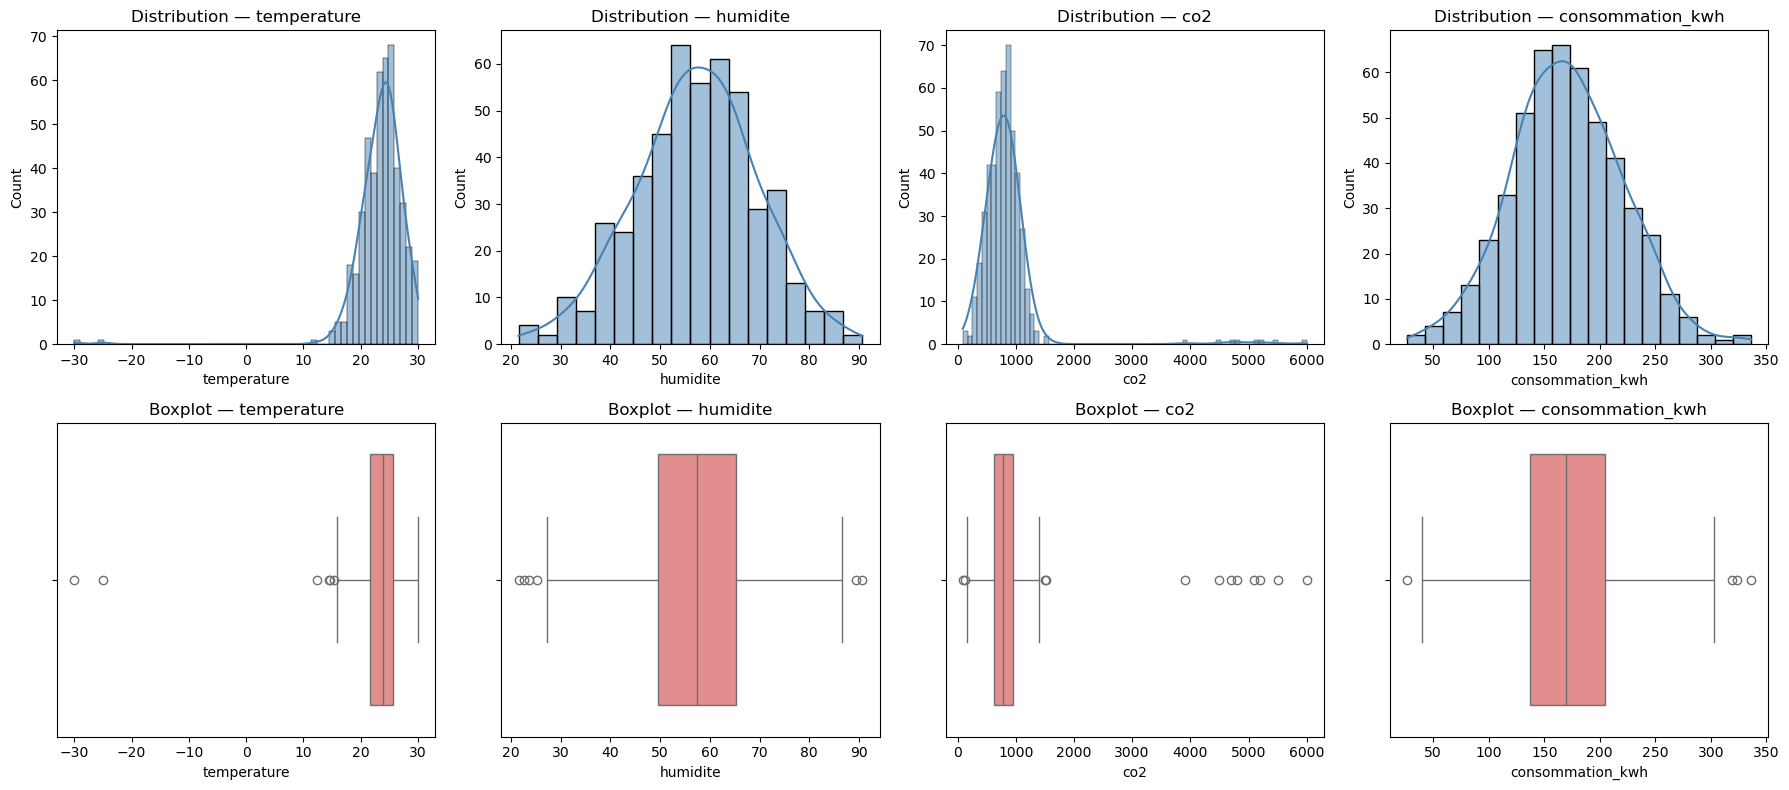

In [95]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

for i, col in enumerate(cols_a_visualiser):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution — {col}")
    sns.boxplot(x=df[col].dropna(), ax=axes[1, i], color="lightcoral")
    axes[1, i].set_title(f"Boxplot — {col}")

plt.tight_layout()
plt.show()


**a) Les distributions (symétrique ou non)**

`temperature` et `humidite` ont des distributions proches de la symétrie (phénomène gaussien).
`co2` et `consommation_kwh` sont plutôt **asymétriques à droite** : quelques valeurs élevées
étirent la queue de distribution.

**b) La dispersion**

Visible via l'écart-type (Partie 1.10) et la largeur des boîtes à moustaches ci-dessus ;
`co2` et `consommation_kwh` sont les variables les plus dispersées en valeur relative.

**c) Les valeurs extrêmes**

Les boxplots font ressortir des points au-delà des moustaches, notamment sur `co2` (valeur
extrême isolée) et `consommation_kwh`.

**d) Les valeurs potentiellement aberrantes**

Une méthode objective (IQR) permet de les quantifier — voir Partie 1.16 ci-dessous.


## 16) Quelle stratégie utiliser pour les valeurs aberrantes ?

In [96]:
def bornes_iqr(serie, k=1.5):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in cols_a_visualiser:
    low, high = bornes_iqr(df[col].dropna())
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:20s} bornes IQR = [{low:8.2f}, {high:8.2f}]  -> {n_out} valeurs hors bornes")


temperature          bornes IQR = [   15.45,    31.85]  -> 6 valeurs hors bornes
humidite             bornes IQR = [   25.80,    89.00]  -> 6 valeurs hors bornes
co2                  bornes IQR = [  132.00,  1444.00]  -> 12 valeurs hors bornes
consommation_kwh     bornes IQR = [   36.60,   305.40]  -> 4 valeurs hors bornes


On distingue deux cas :
- Les valeurs **aberrantes déjà transformées en NaN** en 1.12 (impossibles physiquement) :
  elles seront gérées par l'**imputation** (médiane) du pipeline de preprocessing (Partie 6).
- Les **outliers "plausibles"** détectés par la méthode IQR (ex. pics réels de consommation ou
  de CO₂ lors d'une forte occupation) : on choisit de les **conserver**, car ils correspondent
  potentiellement aux anomalies mêmes que le modèle doit apprendre à détecter (rappel du
  contexte : *"détecter les situations anormales"*). Leur influence sera limitée via la
  **standardisation** (Partie 5) plutôt qu'en les excluant.


## 17) Afficher la fréquence des :

**a) bâtiments**

In [97]:
df["batiment"].value_counts()


batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64

**b) types de bâtiments**

In [98]:
df["type_batiment"].value_counts()


type_batiment
Bureau               211
Centre commercial     65
École                 59
Hôpital               58
Entrepôt              53
Université            49
Name: count, dtype: int64

**c) modes de climatisation**

In [99]:
df["mode_climatisation"].value_counts()


mode_climatisation
Normal    267
Eco       130
Boost      97
Name: count, dtype: int64

**d) états du système**

In [100]:
df["etat_systeme"].value_counts()


etat_systeme
Normal    436
Alerte     52
Name: count, dtype: int64

**e) classes alerte**

In [101]:
df["alerte"].value_counts()


alerte
Non    356
Oui    144
Name: count, dtype: int64

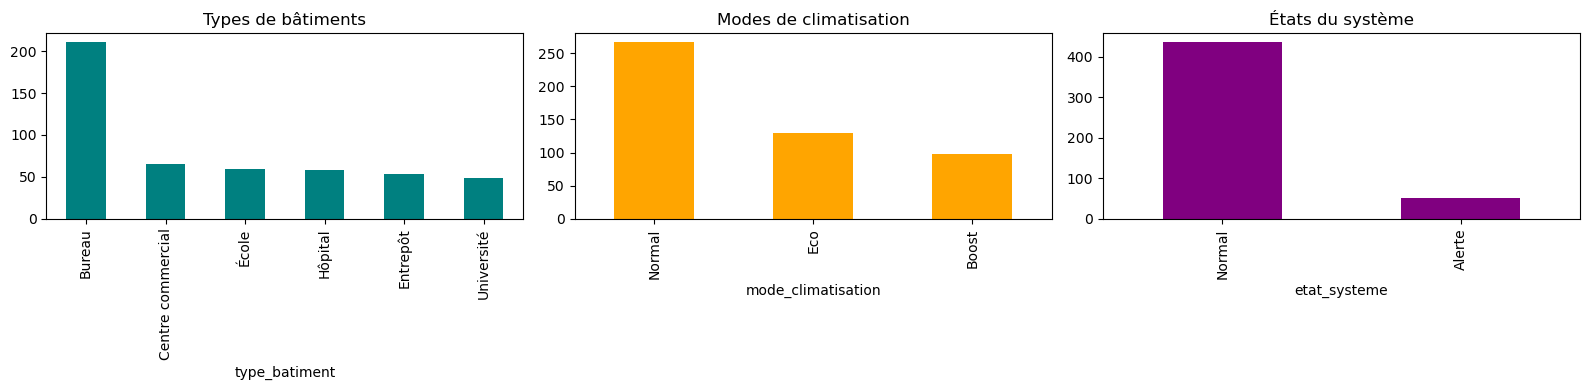

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["type_batiment"].value_counts().plot(kind="bar", ax=axes[0], color="teal", title="Types de bâtiments")
df["mode_climatisation"].value_counts().plot(kind="bar", ax=axes[1], color="orange", title="Modes de climatisation")
df["etat_systeme"].value_counts().plot(kind="bar", ax=axes[2], color="purple", title="États du système")
plt.tight_layout()
plt.show()


## 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

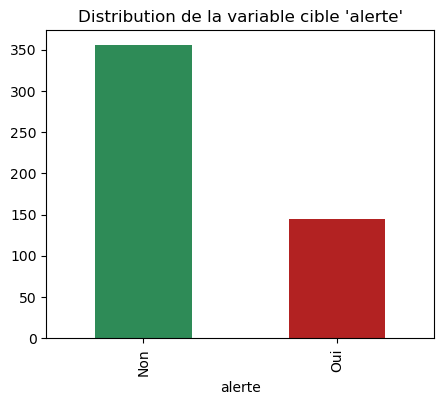

alerte
Non    71.2 %
Oui    28.8 %
Name: proportion, dtype: object


In [103]:
alerte_counts = df["alerte"].value_counts()
alerte_pct = df["alerte"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
alerte_counts.plot(kind="bar", color=["seagreen", "firebrick"], ax=ax)
ax.set_title("Distribution de la variable cible 'alerte'")
plt.show()

print(alerte_pct.round(2).astype(str) + " %")


In [104]:
ratio = alerte_counts.max() / alerte_counts.min()
print(f"Ratio majoritaire/minoritaire ≈ {ratio:.1f} : 1")
print("=> Oui, il y a un déséquilibre de classes marqué (classe 'Oui' fortement minoritaire).")
print("   Pistes : stratification lors du split train/test (Partie 3), métriques adaptées "
      "(F1, precision/recall, AUC-PR plutôt que l'accuracy seule), et éventuellement "
      "rééquilibrage (SMOTE, sous-échantillonnage, class_weight='balanced').")


Ratio majoritaire/minoritaire ≈ 2.5 : 1
=> Oui, il y a un déséquilibre de classes marqué (classe 'Oui' fortement minoritaire).
   Pistes : stratification lors du split train/test (Partie 3), métriques adaptées (F1, precision/recall, AUC-PR plutôt que l'accuracy seule), et éventuellement rééquilibrage (SMOTE, sous-échantillonnage, class_weight='balanced').


## 19) Pour la corrélation sur les variables numériques :

**a) visualiser avec seaborn, la matrice de corrélation**

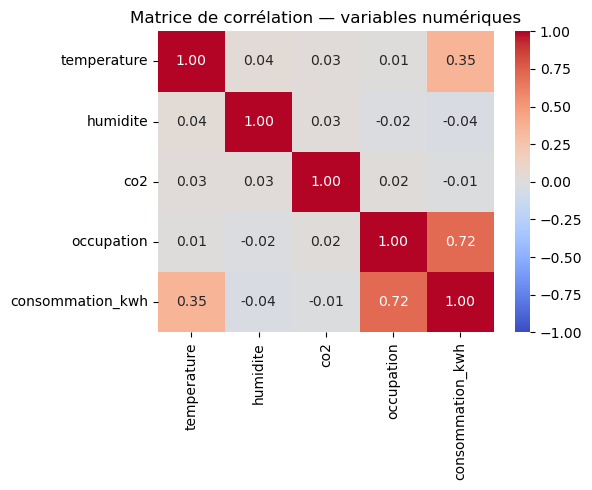

,temperature,humidite,co2,occupation,consommation_kwh
temperature,1.000000,0.039986,0.025913,0.012618,0.353228
humidite,0.039986,1.000000,0.028554,-0.020589,-0.036326
co2,0.025913,0.028554,1.000000,0.017836,-0.009514
occupation,0.012618,-0.020589,0.017836,1.000000,0.718195
consommation_kwh,0.353228,-0.036326,-0.009514,0.718195,1.000000


In [105]:
numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]
corr = df[numeriques].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()

corr


**b) identifier les corrélations positives, négatives et les variables faiblement corrélées**

In [106]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values()
print("Corrélations les plus négatives :")
print(corr_pairs.head(3))
print("\nCorrélations les plus positives :")
print(corr_pairs.tail(3))
print("\nCorrélations proches de 0 (variables faiblement corrélées) :")
print(corr_pairs[corr_pairs.abs() < 0.1])


Corrélations les plus négatives :
humidite  consommation_kwh   -0.036326
          occupation         -0.020589
co2       consommation_kwh   -0.009514
dtype: float64

Corrélations les plus positives :
temperature  humidite            0.039986
             consommation_kwh    0.353228
occupation   consommation_kwh    0.718195
dtype: float64

Corrélations proches de 0 (variables faiblement corrélées) :
humidite     consommation_kwh   -0.036326
             occupation         -0.020589
co2          consommation_kwh   -0.009514
temperature  occupation          0.012618
co2          occupation          0.017836
temperature  co2                 0.025913
humidite     co2                 0.028554
temperature  humidite            0.039986
dtype: float64


**Lecture** : `consommation_kwh` et `occupation` sont **positivement corrélées** (plus de
personnes présentes → plus de consommation), ce qui est cohérent avec la logique métier. Les
autres paires de variables sont **faiblement corrélées** entre elles : aucune paire ne nécessite
d'être retirée pour colinéarité.


### 1) Définir la variable "alerte" comme la cible y

In [40]:
TARGET = "alerte"
y = df[TARGET].copy()


### 2) Trouver des variables explicatives X pertinentes

On retire de X :
- `id_mesure` : identifiant technique, sans valeur prédictive ;
- `batiment` : forte cardinalité (8 valeurs) redondante avec `type_batiment` + `zone`, qui
  résument déjà l'information pertinente pour la généralisation à de nouveaux bâtiments ;
- `date` : gardée sous forme de variables dérivées plus exploitables (mois, heure) ;
- `alerte` : c'est la cible, elle ne doit jamais être dans X.


In [41]:
df["mois"] = df["date"].dt.month
df["heure"] = df["date"].dt.hour

features = [
    "type_batiment", "zone", "temperature", "humidite", "co2",
    "occupation", "consommation_kwh", "mode_climatisation", "etat_systeme",
    "jour_semaine", "mois", "heure",
]
X = df[features].copy()

num_features = ["temperature", "humidite", "co2", "occupation", "consommation_kwh", "mois", "heure"]
cat_features = ["type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine"]

print("Variables explicatives (X) :", features)


Variables explicatives (X) : ['type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'mois', 'heure']


### 3) Afficher les cinq premières lignes de X ainsi que de y

In [42]:
display(X.head())
display(y.head())


,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,mois,heure
0,École,B,25.049344,54.074180,601.516236,72.0,142.594613,Boost,Maintenance,Mardi,3,0
1,Université,D,20.922369,51.893558,766.751033,14.0,235.252870,Normal,Alerte,Vendredi,1,0
2,Entrepôt,A,23.025435,44.393997,NaN,46.0,241.886309,Normal,Normal,Mercredi,3,12
3,Université,C,19.808978,NaN,789.208025,37.0,221.379645,Boost,Maintenance,Samedi,2,0
4,Bureau,B,21.246899,44.512620,583.642537,62.0,238.355007,Eco,Normal,Vendredi,1,18


0    Non
1    Non
2    Oui
3    Oui
4    Non
Name: alerte, dtype: str

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,   # reproductibilité
    stratify=y,                  # conserve les proportions de classes malgré le déséquilibre
)

print("Taille train :", X_train.shape, " Taille test :", X_test.shape)
print("\nProportions dans y (original) :")
print(y.value_counts(normalize=True).round(3))
print("\nProportions dans y_train :")
print(y_train.value_counts(normalize=True).round(3))
print("\nProportions dans y_test :")
print(y_test.value_counts(normalize=True).round(3))


Taille train : (400, 12)  Taille test : (100, 12)

Proportions dans y (original) :
alerte
Non    0.896
Oui    0.104
Name: proportion, dtype: float64

Proportions dans y_train :
alerte
Non    0.895
Oui    0.105
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
Non    0.9
Oui    0.1
Name: proportion, dtype: float64


On a 5 variables catégorielles explicatives : `type_batiment`, `zone`,
`mode_climatisation`, `etat_systeme`, `jour_semaine`.

- Elles sont toutes **nominales** (pas d'ordre naturel entre les modalités) et à **faible
  cardinalité** (3 à 7 modalités) → **One-Hot Encoding** est le choix le plus adapté : il évite
  d'introduire un ordre artificiel (ce que ferait un simple Label/Ordinal Encoding) et reste
  compact vu le faible nombre de catégories.
- La cible `alerte` est binaire : un simple mapping 0/1 suffit, sans risque d'introduire une
  relation d'ordre puisqu'il n'y a que 2 classes.
- Si `batiment` (8 modalités) avait été conservé dans X, un encodage fréquentiel ou un
  Target Encoding aurait pu être envisagé pour limiter la dimensionnalité — mais on ne l'a pas
  retenu comme feature (Partie 2).

Démonstration manuelle avant intégration dans le pipeline Scikit-learn :


In [44]:
demo_ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
demo_encoded = demo_ohe.fit_transform(X_train[cat_features])
demo_df = pd.DataFrame(demo_encoded, columns=demo_ohe.get_feature_names_out(cat_features))
demo_df.head()


,type_batiment_Bureau,type_batiment_Centre commercial,type_batiment_Entrepôt,type_batiment_Hôpital,type_batiment_Université,type_batiment_École,zone_A,zone_B,zone_C,zone_D,mode_climatisation_Boost,mode_climatisation_Eco,mode_climatisation_Normal,etat_systeme_Alerte,etat_systeme_Maintenance,etat_systeme_Normal,jour_semaine_Dimanche,jour_semaine_Jeudi,jour_semaine_Lundi,jour_semaine_Mardi,jour_semaine_Mercredi,jour_semaine_Samedi,jour_semaine_Vendredi
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [45]:
y_train_enc = y_train.map({"Non": 0, "Oui": 1})
y_test_enc = y_test.map({"Non": 0, "Oui": 1})
y_train_enc.head()


182    1
177    0
457    0
429    0
135    1
Name: alerte, dtype: int64

### 1) A l'aide de quelques variables, justifier la pertinence de la mise à l'échelle

In [46]:
X_train[num_features].agg(["mean", "std", "min", "max"]).T

,mean,std,min,max
temperature,21.758301,3.995195,-19.724536,29.707375
humidite,55.167051,12.146029,11.067018,92.777664
co2,770.496421,346.641171,128.611316,6000.000000
occupation,44.826873,21.894199,0.000000,114.000000
consommation_kwh,186.813750,49.626461,55.927948,344.042017
mois,3.072500,1.420312,1.000000,5.000000
heure,9.060000,6.966903,0.000000,18.000000


Les variables numériques n'ont pas du tout la même échelle : `co2` évolue sur des
centaines de ppm, `heure` va de 0 à 23, `occupation` reste à deux chiffres. Un modèle sensible
aux distances ou aux gradients (k-NN, SVM, régression logistique, réseaux de neurones...)
donnerait artificiellement plus de poids à `co2` simplement à cause de son échelle plus grande.

### 2) Appliquer et justifier une technique de mise à l'échelle

On choisit la **standardisation** (`StandardScaler`, moyenne 0, écart-type 1) plutôt qu'une
normalisation min-max, car certaines variables (`consommation_kwh`, `co2`) contiennent encore
des valeurs extrêmes légitimes : le `StandardScaler` est moins écrasé par ces valeurs qu'un
`MinMaxScaler`, qui aurait compressé l'essentiel des données dans un petit intervalle.


In [47]:
scaler_demo = StandardScaler()
X_train_scaled_demo = scaler_demo.fit_transform(X_train[num_features])
pd.DataFrame(X_train_scaled_demo, columns=num_features).agg(["mean", "std"]).round(2).T


,mean,std
temperature,-0.0,1.0
humidite,0.0,1.0
co2,0.0,1.0
occupation,0.0,1.0
consommation_kwh,0.0,1.0
mois,0.0,1.0
heure,-0.0,1.0


### 3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?

Si on calcule la moyenne et l'écart-type du `StandardScaler` sur **l'ensemble du dataset**
(train + test), ces statistiques "voient" indirectement les données de test avant
l'entraînement : c'est une **fuite de données (data leakage)**. Le modèle serait alors évalué
de façon trop optimiste, car le test ne serait plus réellement "inconnu" au moment du fit. La
bonne pratique est de `fit` le scaler **uniquement sur le train**, puis d'appliquer
`transform` (sans refit) sur le test — c'est exactement ce que garantit le `Pipeline`
Scikit-learn de la Partie 6, combiné au split fait en amont (Partie 3).


In [48]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
])

full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
])

full_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [49]:
# Fit UNIQUEMENT sur le train (pas de fuite de données), puis transform sur train et test
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

feature_names_out = full_pipeline.named_steps["preprocessing"].get_feature_names_out()

print("Shape X_train préparé :", X_train_prepared.shape)
print("Shape X_test préparé  :", X_test_prepared.shape)

X_train_prepared_df = pd.DataFrame(X_train_prepared, columns=feature_names_out, index=X_train.index)
X_train_prepared_df.head()


Shape X_train préparé : (400, 30)
Shape X_test préparé  : (100, 30)


,num__temperature,num__humidite,num__co2,num__occupation,num__consommation_kwh,num__mois,num__heure,cat__type_batiment_Bureau,cat__type_batiment_Centre commercial,cat__type_batiment_Entrepôt,cat__type_batiment_Hôpital,cat__type_batiment_Université,cat__type_batiment_École,cat__zone_A,cat__zone_B,cat__zone_C,cat__zone_D,cat__mode_climatisation_Boost,cat__mode_climatisation_Eco,cat__mode_climatisation_Normal,cat__etat_systeme_Alerte,cat__etat_systeme_Maintenance,cat__etat_systeme_Normal,cat__jour_semaine_Dimanche,cat__jour_semaine_Jeudi,cat__jour_semaine_Lundi,cat__jour_semaine_Mardi,cat__jour_semaine_Mercredi,cat__jour_semaine_Samedi,cat__jour_semaine_Vendredi
182,1.514001,0.232198,0.335326,0.007788,1.783887,0.653843,0.422524,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
177,-0.844890,0.994021,-0.521654,-2.037995,-1.650133,1.358795,1.284817,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
457,-0.218008,0.813524,-0.671046,-0.271182,-1.461990,1.358795,-1.302063,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
429,0.719788,0.699654,-0.043502,0.007788,-1.274945,-0.051109,0.422524,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
135,-0.999936,1.306538,-0.700564,0.705214,1.124803,1.358795,0.422524,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Ce pipeline correspond exactement au schéma demandé :

```
Dataset brut → Séparation X/y → Train/Test → {num: imputation médiane + StandardScaler,
cat: imputation mode + OneHotEncoder} → Dataset préparé → Modèle de ML
```


In [50]:
EXPORT_PATH = "../exports/smart_building_cleaned.csv"

df_cleaned = df.copy()
df_cleaned.to_csv(EXPORT_PATH, index=False)
print(f"Dataset nettoyé exporté vers : {EXPORT_PATH}")
print("Shape finale :", df_cleaned.shape)
df_cleaned.head()


Dataset nettoyé exporté vers : ../exports/smart_building_cleaned.csv
Shape finale : (500, 16)


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte,mois,heure
0,1102,2025-03-11 00:00:00,B4,École,B,25.049344,54.074180,601.516236,72.0,142.594613,Boost,Maintenance,Mardi,Non,3,0
1,1238,2025-01-10 00:00:00,B4,Université,D,20.922369,51.893558,766.751033,14.0,235.252870,Normal,Alerte,Vendredi,Non,1,0
2,1318,2025-03-05 12:00:00,B3,Entrepôt,A,23.025435,44.393997,NaN,46.0,241.886309,Normal,Normal,Mercredi,Oui,3,12
3,1490,2025-02-08 00:00:00,B6,Université,C,19.808978,NaN,789.208025,37.0,221.379645,Boost,Maintenance,Samedi,Oui,2,0
4,1268,2025-01-03 18:00:00,B3,Bureau,B,21.246899,44.512620,583.642537,62.0,238.355007,Eco,Normal,Vendredi,Non,1,18


Quelques fonctionnalités supplémentaires pertinentes pour prolonger l'atelier :

1. **Feature engineering temporel avancé** : encoder `heure` et `mois` de façon cyclique
   (sin/cos) plutôt qu'en valeurs brutes, pour éviter la discontinuité artificielle entre
   23h et 0h ou décembre/janvier.
2. **Détection d'anomalies non supervisée** : comparer une approche supervisée (classification
   sur `alerte`) à une approche non supervisée (Isolation Forest, Local Outlier Factor) pour
   détecter les situations anormales sans dépendre du label.
3. **Gestion du déséquilibre de classes** : comparer `class_weight="balanced"`,
   sur-échantillonnage SMOTE et sous-échantillonnage sur un modèle simple, et comparer les
   métriques F1 / AUC-PR.
4. **Feature engineering par bâtiment** : agréger l'historique par `batiment` (moyenne
   glissante de consommation, écart à la moyenne du bâtiment) pour donner du contexte au
   modèle sans réintroduire `batiment` brut (évite l'explosion du One-Hot).
5. **Rapport de qualité automatisé** : générer un rapport de data quality à chaque nouvelle
   ingestion de données brutes, pour industrialiser le monitoring de la qualité des données en
   amont du pipeline ML.

Démonstration rapide du point 1 (encodage cyclique de l'heure) :


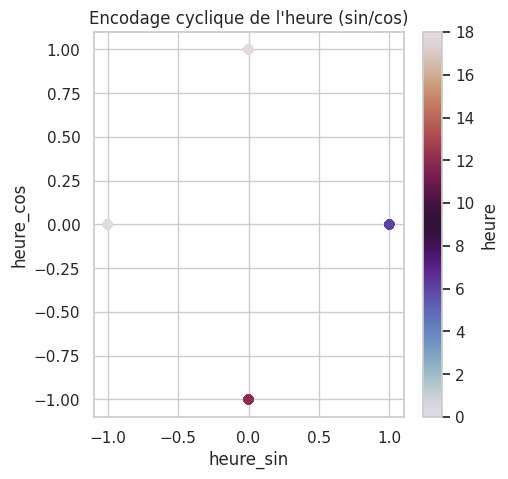

In [51]:
df_cleaned["heure_sin"] = np.sin(2 * np.pi * df_cleaned["heure"] / 24)
df_cleaned["heure_cos"] = np.cos(2 * np.pi * df_cleaned["heure"] / 24)

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(df_cleaned["heure_sin"], df_cleaned["heure_cos"], c=df_cleaned["heure"], cmap="twilight")
ax.set_title("Encodage cyclique de l'heure (sin/cos)")
ax.set_xlabel("heure_sin")
ax.set_ylabel("heure_cos")
plt.colorbar(sc, label="heure")
plt.show()


---
# Partie 2 – Séparation X / y

### 1) Définir la variable "alerte" comme la cible y

In [107]:
cible = "alerte"
y = df[cible].copy()